In [1]:
# mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.1 MB/s eta 0:00:00


In [23]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# load the 2025 USEP dataset from Google Drive
filepath = "/content/drive/MyDrive/Singapore Forecasting Electricity Price/usep_data_2025.xlsx"
# read the Excel file into a pandas dataframe for preprocessing and modelling
usep_df = pd.read_excel(filepath)
# display the first 5 rows to verify the data structure and columns
usep_df.head()

,DATE,USEP,DEMAND,SOLAR
0,2025-01-01,93.600833,5930.052583,158.514792
1,2025-01-02,87.035833,6358.067917,162.426042
2,2025-01-03,105.036667,6407.756771,174.522083
3,2025-01-04,111.137083,6158.840583,177.016875
4,2025-01-05,99.658542,5989.193917,176.524375


# **ARIMA**

In [5]:
# create a stationary time series by calculating the first-order difference
usep_diff = np.log(usep_df['USEP']).diff().dropna()

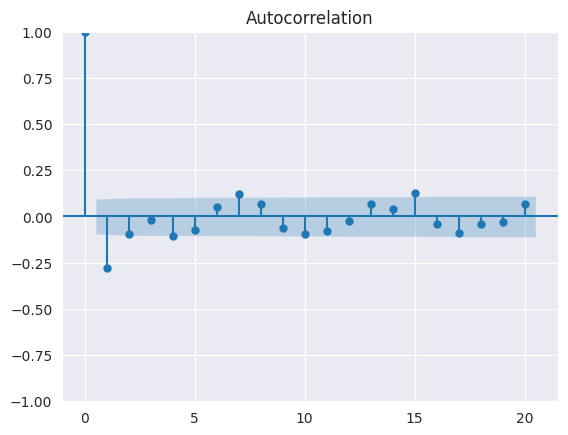

In [6]:
# plot the autocorrelation function (ACF) to identify the MA
sns.set_style("darkgrid")
plot_acf(usep_diff, lags = 20)
plt.show()

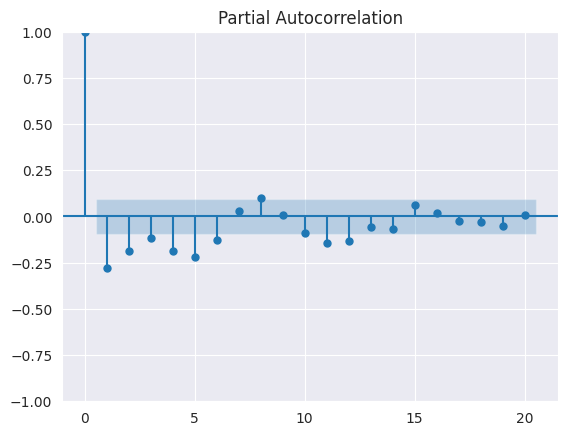

In [7]:
# plot the partial autocorrelation function (PACF) to identify AR
plot_pacf(usep_diff, lags = 20)
plt.show()

In [8]:
# initialize ARIMA model
arima_model = ARIMA(usep_df['USEP'], order = (1, 1, 1))
# fit the model parameters
arima_results = arima_model.fit()
# display the estimation summary
print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                   USEP   No. Observations:                  423
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2095.606
Date:                Sun, 24 May 2026   AIC                           4197.212
Time:                        04:54:31   BIC                           4209.347
Sample:                             0   HQIC                          4202.007
                                - 423                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3888      0.039     10.069      0.000       0.313       0.465
ma.L1         -0.9181      0.022    -42.190      0.000      -0.961      -0.875
sigma2      1201.3733     23.491     51.142      0.0

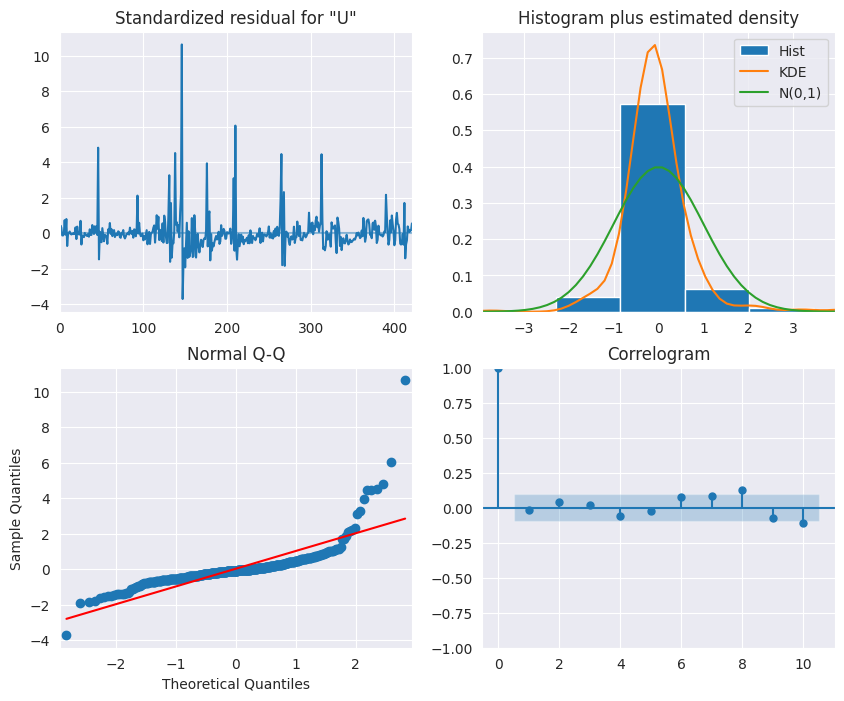

In [9]:
# generate diagnostic plots for the fitted ARIMA model
arima_results.plot_diagnostics(figsize = (10, 8))
plt.show()

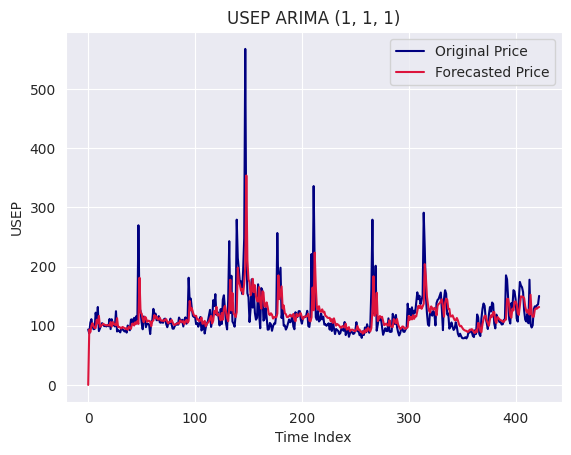

In [10]:
# plot the actual USEP and the forecasted USEP based on ARIMA model
forecast = arima_results.predict(start = usep_df.index[0], end = usep_df.index[-1])
plt.plot(usep_df['USEP'], color = "navy", label = "Original Price")
plt.plot(forecast, color = "crimson", label = "Forecasted Price")
plt.title("USEP ARIMA (1, 1, 1)")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

# **GARCH**

In [11]:
# extract the raw residuals from the fitted ARIMA model
residuals = arima_results.resid

In [12]:
# initialize the GARCH model to analyze the volatility
garch_model = arch_model(residuals, p = 1, q = 1, vol = "GARCH", dist = "t")
# fit the GARCH model parameters to the residuals
garch_results = garch_model.fit(disp = 0)
# print the parameter estimations
print(garch_results.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1857.75
Distribution:      Standardized Student's t   AIC:                           3725.51
Method:                  Maximum Likelihood   BIC:                           3745.74
                                              No. Observations:                  423
Date:                      Sun, May 24 2026   Df Residuals:                      422
Time:                              04:54:35   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -3

# **Feature Engineering**

In [13]:
# create a new feature by shifting the ARIMA residuals backward by one time step
usep_df['lag1'] = usep_df['USEP'].shift(1)

In [14]:
usep_df['arima_residuals_lag1'] = residuals.shift(1)

In [15]:
# create a new feature by extracting the garch residuals
usep_df['garch_residual'] = garch_results.resid

In [16]:
# create a new feature by calculating the standardized residuals from the GARCH model
usep_df['garch_std_resid'] = garch_results.resid/ garch_results.conditional_volatility

In [17]:
# drop all rows containing missing values (NaNs)
usep_df = usep_df.dropna()
usep_df.head()

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,2025-01-02,87.035833,6358.067917,162.426042,93.600833,93.600833,-2.975884,-0.037788
2,2025-01-03,105.036667,6407.756771,174.522083,87.035833,-6.519986,19.596266,0.387500
3,2025-01-04,111.137083,6158.840583,177.016875,105.036667,16.052163,14.834500,0.402655
4,2025-01-05,99.658542,5989.193917,176.524375,111.137083,11.290398,-1.259383,-0.044884
5,2025-01-06,94.180833,6446.642542,176.036458,99.658542,-4.803486,-1.453462,-0.070010


In [18]:
# compute the pairwise pearson correlation coefficients for all numerical columns.
usep_df.corr(method = "spearman")

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
DATE,1.000000,0.070640,0.103216,0.418540,0.069047,-0.024640,-0.012412,-0.040243
USEP,0.070640,1.000000,0.540707,0.028812,0.685872,0.328700,0.578880,0.611230
DEMAND,0.103216,0.540707,1.000000,-0.051947,0.405253,0.177026,0.223944,0.240115
SOLAR,0.418540,0.028812,-0.051947,1.000000,0.075969,0.007806,0.002070,-0.008009
lag1,0.069047,0.685872,0.405253,0.075969,1.000000,0.569461,0.017546,0.023949
arima_residuals_lag1,-0.024640,0.328700,0.177026,0.007806,0.569461,1.000000,0.211965,0.203074
garch_residual,-0.012412,0.578880,0.223944,0.002070,0.017546,0.211965,1.000000,0.968750
garch_std_resid,-0.040243,0.611230,0.240115,-0.008009,0.023949,0.203074,0.968750,1.000000


In [19]:
# drop the irrelevant columns
usep_df = usep_df.drop(columns = ['DATE', 'DEMAND', 'SOLAR'])
usep_df.head()

,USEP,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,87.035833,93.600833,93.600833,-2.975884,-0.037788
2,105.036667,87.035833,-6.519986,19.596266,0.387500
3,111.137083,105.036667,16.052163,14.834500,0.402655
4,99.658542,111.137083,11.290398,-1.259383,-0.044884
5,94.180833,99.658542,-4.803486,-1.453462,-0.070010


# **Data Splitting**

In [20]:
# separate the features from the target
X = usep_df.drop(columns = ['USEP'])
y = usep_df['USEP']

In [21]:
# split the features into training and testing sets
X_train, X_test = X.iloc[:366], X.iloc[366:]
y_train, y_test = y.iloc[:366], y.iloc[366:]

# **Model Training**

In [24]:
# initialize the base random forest regressor
rfr = RandomForestRegressor(random_state = 42)

# define the hyperparameter grid
param_grid = {'n_estimators': [50, 60, 70, 80, 90, 100],
              'max_depth': [8, 9, 10],
              'min_samples_leaf': [1, 2, 3, 4, 5],
              'min_samples_split': [2, 3, 4, 5]}

# set up time series split
tscv = TimeSeriesSplit(n_splits = 5)

# set up the grid search cross-validation configuration
grid_search = GridSearchCV(estimator = rfr,
                           param_grid = param_grid,
                           cv = tscv,
                           n_jobs = 1,
                           verbose = 3,
                           scoring = 'neg_mean_squared_error',
                           return_train_score = True,
                           refit = True)

# execute the search over all parameter combination
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
[CV 1/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=-60.899, test=-155.400) total time=   0.1s
[CV 2/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=-12.930, test=-3341.980) total time=   0.1s
[CV 3/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=-140.905, test=-199.119) total time=   0.1s
[CV 4/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=-110.069, test=-88.439) total time=   0.1s
[CV 5/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=-59.521, test=-76.705) total time=   0.1s
[CV 1/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=60;, score=(train=-51.786, test=-153.056) total time=   0.1s
[CV 2/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=60;, scor

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=1,
             param_grid={'max_depth': [8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [50, 60, 70, 80, 90, 100]},
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=3)

In [25]:
# display the best score achieved during the grid search optimization
print(grid_search.best_score_)

-706.6194354494473


In [26]:
# display the specific combination of hyperparameters that achieved the lowest error score during the grid search cv
print(grid_search.best_params_)

{'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 60}


# **Model Evaluation**

In [27]:
# use the optimized refitted random forest model to predict the price for the training set and testing set
y_pred_train = grid_search.predict(X_train)
y_pred_test = grid_search.predict(X_test)

In [28]:
# compute the evaluation for the training set
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

In [29]:
# compute the evaluation for the testing set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [30]:
# display the evaluation results for the training set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_train))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_train)))
print("R-squared (R2) Score: {:.4f}".format(r2_train))

Mean Absolute Error (MAE): 3.7303
Root Mean Squared Error (MSE): 10.8280
R-squared (R2) Score: 0.9344


In [31]:
# display the evaluation results for the testing set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_test))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_test)))
print("R-squared (R2) Score: {:.4f}".format(r2_test))

Mean Absolute Error (MAE): 6.1488
Root Mean Squared Error (MSE): 7.6781
R-squared (R2) Score: 0.8992


In [32]:
# extract the feature importances scores from the optimized random forest model
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index = X.columns)
# sort the features in descending order
importances.sort_values(ascending = False)

,0
garch_residual,0.754632
lag1,0.174075
garch_std_resid,0.047598
arima_residuals_lag1,0.023695


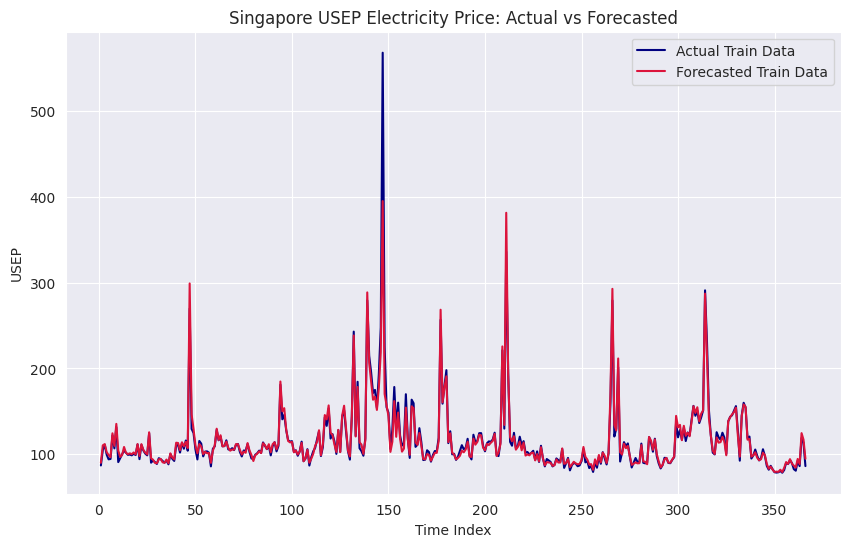

In [33]:
# convert the raw training numpy array predictions into a pandas Series
y_pred_train_series = pd.Series(y_pred_train, index = y_train.index)

# plot the actual vs forecasted USEP electricity price based on training set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_train.index,
         y_train.values, color = "navy", label = "Actual Train Data")
plt.plot(y_pred_train_series.index,
         y_pred_train_series.values, color = "crimson", label = "Forecasted Train Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

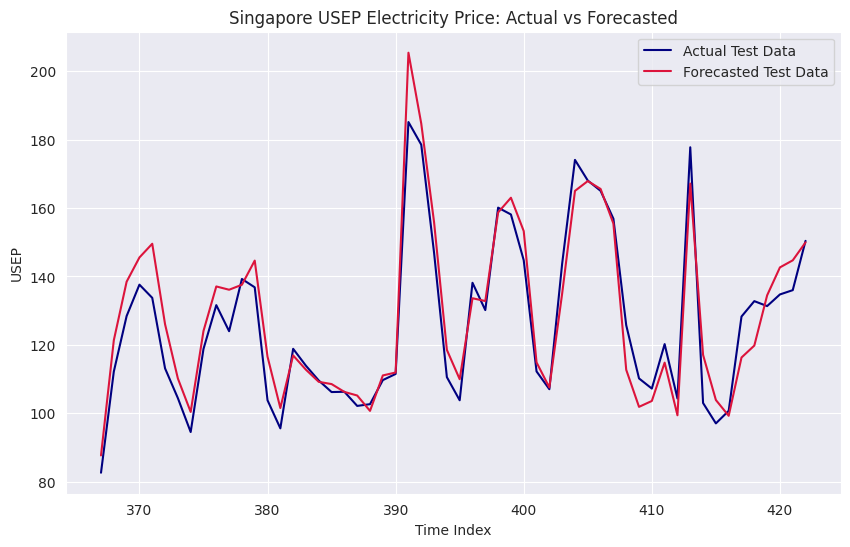

In [34]:
# convert the raw testing numpy array predictions into a pandas Series
y_pred_test_series = pd.Series(y_pred_test, index = y_test.index)

# plot the actual vs forecasted USEP electricity price based on testing set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_test.index,
         y_test.values, color = "navy", label = "Actual Test Data")
plt.plot(y_pred_test_series.index,
         y_pred_test_series.values, color = "crimson", label = "Forecasted Test Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()